<a href="https://colab.research.google.com/github/Srujanasri6/PROJECT-MINI/blob/main/NDVI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:


!wget -q https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/36/N/XC/2023/1/S2A_36NXC_20230115_0_L2A/B04.tif
!wget -q https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/36/N/XC/2023/1/S2A_36NXC_20230115_0_L2A/B08.tif


In [9]:

!pip install rasterio matplotlib -q
import rasterio, numpy as np, matplotlib.pyplot as plt


In [4]:

red = rasterio.open('B04.tif').read(1).astype('float32')
nir = rasterio.open('B08.tif').read(1).astype('float32')
ndvi = (nir - red) / (nir + red + 1e-10)

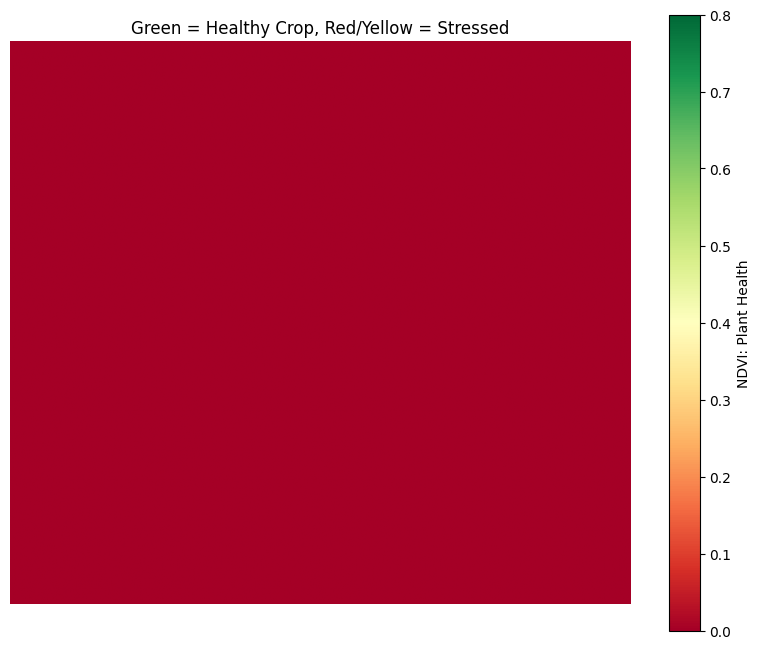

In [10]:
plt.figure(figsize=(10,8))
plt.imshow(ndvi, cmap='RdYlGn', vmin=0, vmax=0.8)
plt.colorbar(label='NDVI: Plant Health')
plt.title('Green = Healthy Crop, Red/Yellow = Stressed')
plt.axis('off')
plt.show()

In [11]:
!rm B04.tif B08.tif

In [31]:
!wget -q https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/36/N/YF/2023/3/S2B_36NYF_20230307_0_L2A/B04.tif
!wget -q https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/36/N/YF/2023/3/S2B_36NYF_20230307_0_L2A/B08.tif

In [33]:
import rasterio, numpy as np, matplotlib.pyplot as plt

In [34]:
!ls -lh B04.tif B08.tif

-rw-r--r-- 1 root root 211M Mar  7  2023 B04.tif
-rw-r--r-- 1 root root 217M Mar  7  2023 B08.tif


In [35]:
!pip install rasterio matplotlib -q
import rasterio, numpy as np, matplotlib.pyplot as plt

In [37]:
red = rasterio.open('B04.tif').read(1).astype('float32')
nir = rasterio.open('B08.tif').read(1).astype('float32')

In [39]:
print("Red min/max:", red.min(), red.max())
print("NIR min/max:", nir.min(), nir.max())
print("Are files identical?", np.array_equal(red, nir))

Red min/max: 2.0 18024.0
NIR min/max: 86.0 11712.0
Are files identical? False


In [40]:
ndvi = (nir - red) / (nir + red + 1e-10)
ndvi = np.clip(ndvi, -1, 1)

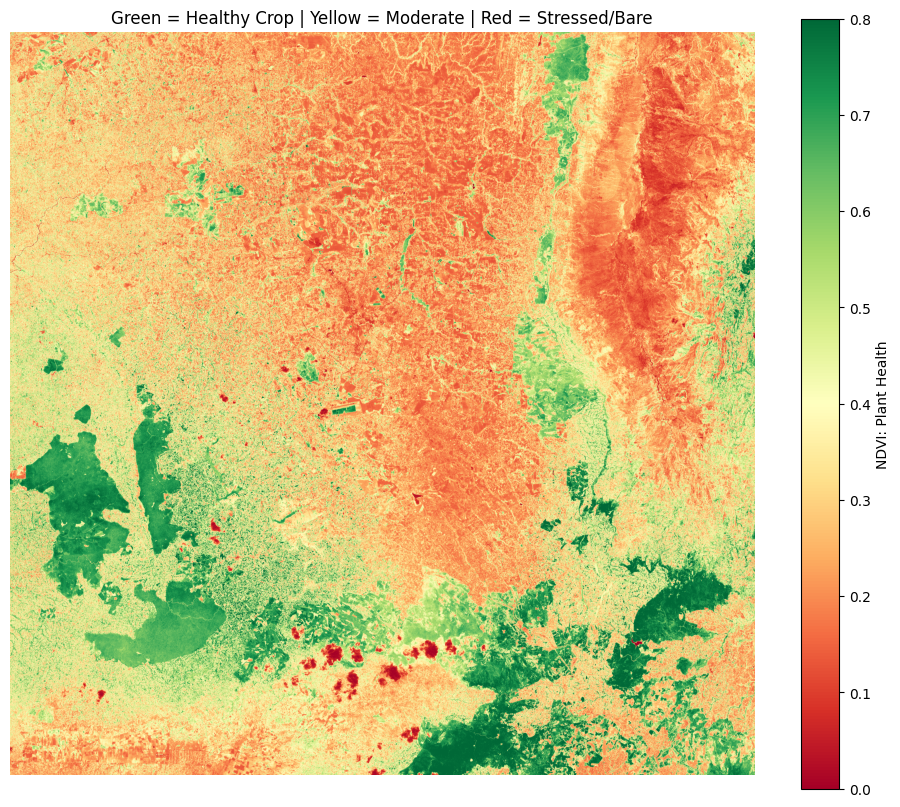

In [41]:
plt.figure(figsize=(12,10))
plt.imshow(ndvi, cmap='RdYlGn', vmin=0.0, vmax=0.8)
plt.colorbar(label='NDVI: Plant Health')
plt.title('Green = Healthy Crop | Yellow = Moderate | Red = Stressed/Bare')
plt.axis('off')
plt.show()

In [42]:
healthy_pixels = np.sum(ndvi > 0.4)
total_pixels = ndvi.size
print(f"Healthy crop area: {healthy_pixels/total_pixels*100:.1f}%")

Healthy crop area: 34.2%
